In [9]:
import numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import utils

ratings=utils.load_ratings()
titles=utils.load_items()
print('Ratings:', ratings.shape)
print('Users:', ratings.user.nunique(), '| Movies:', ratings.item.nunique())

Ratings: (100836, 3)
Users: 610 | Movies: 9724


In [10]:
ratings.head(5)

,user,item,rating
0,1,1,4.0
1,1,3,4.0
2,1,6,4.0
3,1,47,5.0
4,1,50,5.0


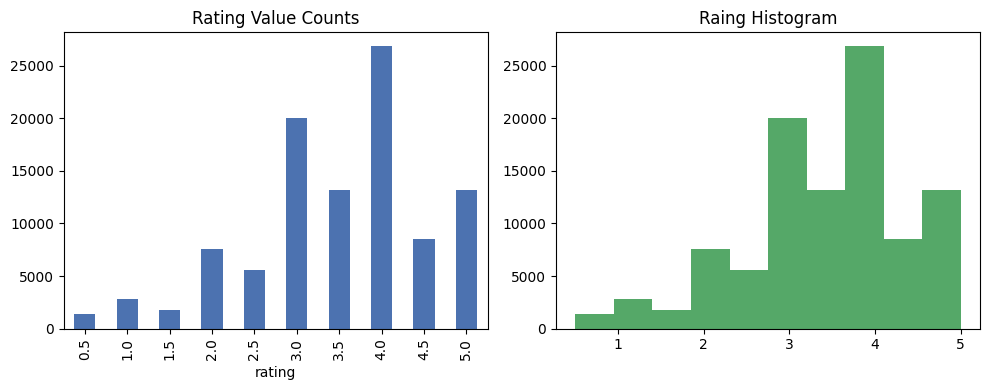

In [15]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')

ax[0].set_title('Rating Value Counts') 
ax[0].set_xlabel('rating')
ax[1].hist(ratings['rating'], bins=10, color='#55a868')
ax[1].set_title('Raing Histogram')
plt.tight_layout()
plt.show()

In [17]:
print('Mean Rating:', round(ratings['rating'].mean(), 2))

Mean Rating: 3.5


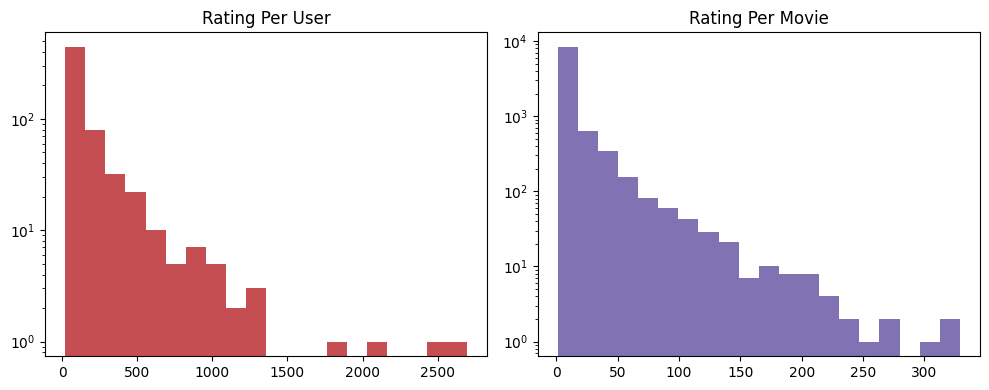

In [21]:
rpu = ratings.groupby('user').size()
rpm = ratings.groupby('item').size()

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(rpu, bins=20, color='#c44e52')
ax[0].set_title('Rating Per User')
ax[0].set_yscale('log')

ax[1].hist(rpm, bins=20, color='#8172b3')
ax[1].set_title('Rating Per Movie')
ax[1].set_yscale('log')

plt.tight_layout()
plt.show()

In [22]:
print('Rating per user - Median %d, max %d' % (rpu.median(), rpu.max()))
print('Rating per moive - Median %d, max %d' % (rpm.median(), rpm.max()))

Rating per user - Median 70, max 2698
Rating per moive - Median 3, max 329


In [26]:
n_users, n_items = ratings.user.nunique(), ratings.item.nunique()
density = len(ratings)/(n_users*n_items)
print(f'full matrix: {n_users} users x {n_items} movies = {n_users*n_items:,} cells')
print(f'observed ratings: {len(ratings):,}')
print('density: %.3f%%  (sparsity %.3f%%)' % (100*density, 100*(1-density)))

full matrix: 610 users x 9724 movies = 5,931,640 cells
observed ratings: 100,836
density: 1.700%  (sparsity 98.300%)


In [30]:
agg = ratings.groupby('item')['rating'].agg(['mean', 'count'])
agg['title'] = agg.index.map(titles)

print('Most Rated:')
print(agg.sort_values('count', ascending=False).head(8)[['title','count','mean']].to_string())

print('\nHighest Rated (>50 ratings):');
print(agg[agg['count']>50].sort_values('count', ascending=False).head(8)[['title','count','mean']].to_string())

Most Rated:
                                          title  count      mean
item                                                            
356                         Forrest Gump (1994)    329  4.164134
318            Shawshank Redemption, The (1994)    317  4.429022
296                         Pulp Fiction (1994)    307  4.197068
593            Silence of the Lambs, The (1991)    279  4.161290
2571                         Matrix, The (1999)    278  4.192446
260   Star Wars: Episode IV - A New Hope (1977)    251  4.231076
480                        Jurassic Park (1993)    238  3.750000
110                           Braveheart (1995)    237  4.031646

Highest Rated (>50 ratings):
                                          title  count      mean
item                                                            
356                         Forrest Gump (1994)    329  4.164134
318            Shawshank Redemption, The (1994)    317  4.429022
296                         Pulp Fiction (1994) 